# **1. Analyse load_digits dataset in sklearn. Conduct PCA and determine the major components that affect your predictions**

In [28]:
import sklearn

from sklearn.datasets import load_digits

In [29]:
# Loading the iris dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

In [30]:
X_digits, y_digits

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 array([0, 1, 2, ..., 8, 9, 8]))

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Scale the features data

In [32]:
scaler = StandardScaler()

In [33]:
# Standardizing the data
scaled_iris = scaler.fit_transform(X_digits)

In [34]:
scaled_iris

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [35]:
# Applying PCA
pca_digits = PCA()

pca_digits.fit(scaled_iris)

PCA()

In [36]:
help(pca_digits)

Help on PCA in module sklearn.decomposition._pca object:

class PCA(sklearn.decomposition._base._BasePCA)
 |  PCA(n_components=None, *, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto', random_state=None)
 |
 |  Principal component analysis (PCA).
 |
 |  Linear dimensionality reduction using Singular Value Decomposition of the
 |  data to project it to a lower dimensional space. The input data is centered
 |  but not scaled for each feature before applying the SVD.
 |
 |  It uses the LAPACK implementation of the full SVD or a randomized truncated
 |  SVD by the method of Halko et al. 2009, depending on the shape of the input
 |  data and the number of components to extract.
 |
 |  With sparse inputs, the ARPACK implementation of the truncated SVD can be
 |  used (i.e. through :func:`scipy.sparse.linalg.svds`). Alternatively, one
 |  may consider :class:`TruncatedSVD` where the data are not centered.
 |
 |  N

In [37]:
# Explained variance ratio
explained_variance_digits = pca_digits.explained_variance_ratio_

In [38]:
explained_variance_digits

array([0.12033916, 0.09561054, 0.08444415, 0.06498408, 0.04860155,
       0.0421412 , 0.03942083, 0.03389381, 0.02998221, 0.02932003,
       0.02781805, 0.02577055, 0.02275303, 0.0222718 , 0.02165229,
       0.01914167, 0.01775547, 0.01638069, 0.0159646 , 0.01489191,
       0.0134797 , 0.01271931, 0.01165837, 0.01057647, 0.00975316,
       0.00944559, 0.00863014, 0.00836643, 0.00797693, 0.00746471,
       0.00725582, 0.00691911, 0.00653909, 0.00640793, 0.00591384,
       0.00571162, 0.00523637, 0.00481808, 0.00453719, 0.00423163,
       0.00406053, 0.00397085, 0.00356493, 0.00340787, 0.00327835,
       0.00311032, 0.00288575, 0.00276489, 0.00259175, 0.00234483,
       0.00218257, 0.00203598, 0.00195512, 0.00183318, 0.00167946,
       0.00161236, 0.00147763, 0.00135118, 0.00125101, 0.00103696,
       0.00082535, 0.        , 0.        , 0.        ])

In [39]:
print(f"Explained variance by each component : {explained_variance_digits}")

Explained variance by each component : [0.12033916 0.09561054 0.08444415 0.06498408 0.04860155 0.0421412
 0.03942083 0.03389381 0.02998221 0.02932003 0.02781805 0.02577055
 0.02275303 0.0222718  0.02165229 0.01914167 0.01775547 0.01638069
 0.0159646  0.01489191 0.0134797  0.01271931 0.01165837 0.01057647
 0.00975316 0.00944559 0.00863014 0.00836643 0.00797693 0.00746471
 0.00725582 0.00691911 0.00653909 0.00640793 0.00591384 0.00571162
 0.00523637 0.00481808 0.00453719 0.00423163 0.00406053 0.00397085
 0.00356493 0.00340787 0.00327835 0.00311032 0.00288575 0.00276489
 0.00259175 0.00234483 0.00218257 0.00203598 0.00195512 0.00183318
 0.00167946 0.00161236 0.00147763 0.00135118 0.00125101 0.00103696
 0.00082535 0.         0.         0.        ]


<Axes: >

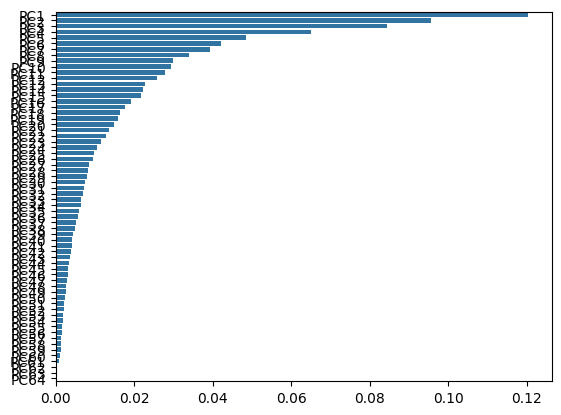

In [40]:
import seaborn as sns
num_components = len(explained_variance_digits)
component_labels = [f'PC{i+1}' for i in range(num_components)]
sns.barplot(x=explained_variance_digits, y=component_labels)

In [41]:
pca_digits.components_

array([[-0.00000000e+00,  1.82233917e-01,  2.85867997e-01, ...,
         1.03198001e-01,  1.19810604e-01,  7.14936163e-02],
       [ 0.00000000e+00,  4.70270076e-02,  5.95647953e-02, ...,
        -2.42617777e-01, -1.65089262e-01, -7.13292370e-02],
       [-0.00000000e+00,  2.35882143e-02, -5.67987457e-02, ...,
        -2.22795243e-02,  1.00365586e-01,  9.24458865e-02],
       ...,
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-0.00000000e+00, -0.00000000e+00,  4.32174768e-17, ...,
         1.02768952e-16, -7.73705309e-17,  2.02213215e-17],
       [ 0.00000000e+00,  0.00000000e+00, -7.89606855e-17, ...,
         1.01601458e-15, -9.24368563e-16,  4.27384548e-16]])

In [42]:
import pandas as pd

In [43]:
# Showing the components (loadings)
components_digits = pd.DataFrame(pca_digits.components_,
                               columns=digits.feature_names)


In [44]:
print("Principal components (loadings) for digits:")
print(components_digits)


Principal components (loadings) for digits:
    pixel_0_0  pixel_0_1     pixel_0_2     pixel_0_3     pixel_0_4  \
0        -0.0   0.182234  2.858680e-01  2.203697e-01 -2.516956e-02   
1         0.0   0.047027  5.956480e-02 -2.080385e-02  1.559032e-01   
2        -0.0   0.023588 -5.679875e-02 -4.046383e-02 -6.706530e-02   
3        -0.0  -0.178153 -1.561285e-01 -1.677999e-01  8.908546e-06   
4        -0.0  -0.029978 -1.466570e-02  4.371583e-02 -1.399930e-01   
..        ...        ...           ...           ...           ...   
59        0.0   0.022867 -1.392809e-01 -1.543367e-02  1.314418e-02   
60       -0.0  -0.026354  6.864465e-01 -1.818844e-02  5.628714e-02   
61        1.0   0.000000  0.000000e+00  0.000000e+00  0.000000e+00   
62       -0.0  -0.000000  4.321748e-17 -4.753897e-17  1.360767e-17   
63        0.0   0.000000 -7.896069e-17 -1.628525e-16  2.140113e-16   

       pixel_0_5     pixel_0_6     pixel_0_7     pixel_1_0     pixel_1_1  ...  \
0  -9.497250e-03 -5.247650e-02 -6.

# **2. Conduct PCA on  Patient Monitoring: dataset provided patient_monitoring.csv**

In [45]:
from google.colab import files
uploaded = files.upload()

Saving patient_monitoring.csv to patient_monitoring.csv


In [46]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('patient_monitoring.csv')

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

First 5 rows:


,Unnamed: 0,heart_rate,sys_bp,dia_bp,ecg,event
0,0,101.0,124.0,79.0,-0.9539,1
1,1,100.0,123.0,80.0,-0.4302,0
2,2,102.0,120.0,78.0,-0.2068,0
3,3,104.0,118.0,79.0,0.9438,0
4,4,100.0,122.0,76.0,0.2783,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   heart_rate  1000 non-null   float64
 2   sys_bp      1000 non-null   float64
 3   dia_bp      1000 non-null   float64
 4   ecg         1000 non-null   float64
 5   event       1000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 47.0 KB


In [48]:
# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Handle missing values
df_numeric = df_numeric.fillna(df_numeric.mean())

print("Shape of numeric data:", df_numeric.shape)

Shape of numeric data: (1000, 6)


In [49]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

In [50]:
pca = PCA()
pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_

print("Explained Variance:\n", explained_variance)

Explained Variance:
 [0.27616083 0.20932845 0.16862594 0.15689021 0.13630502 0.05268956]


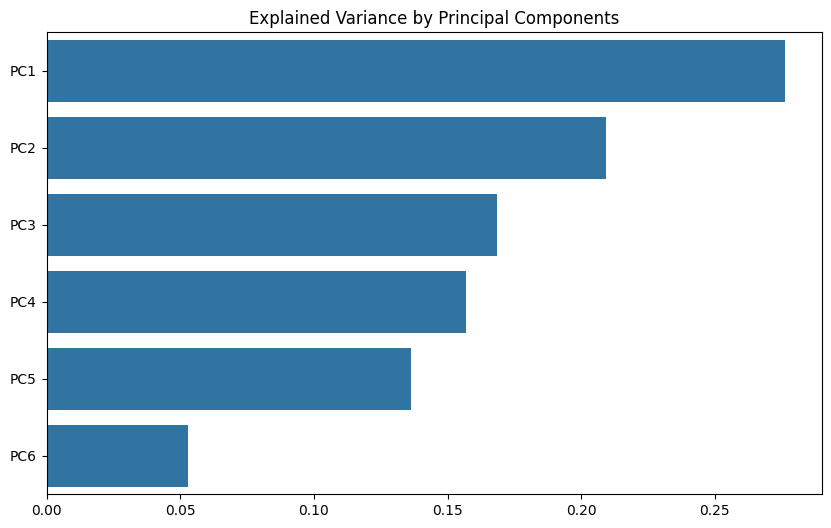

In [51]:
plt.figure(figsize=(10,6))
sns.barplot(x=explained_variance, y=[f'PC{i+1}' for i in range(len(explained_variance))])
plt.title("Explained Variance by Principal Components")
plt.show()

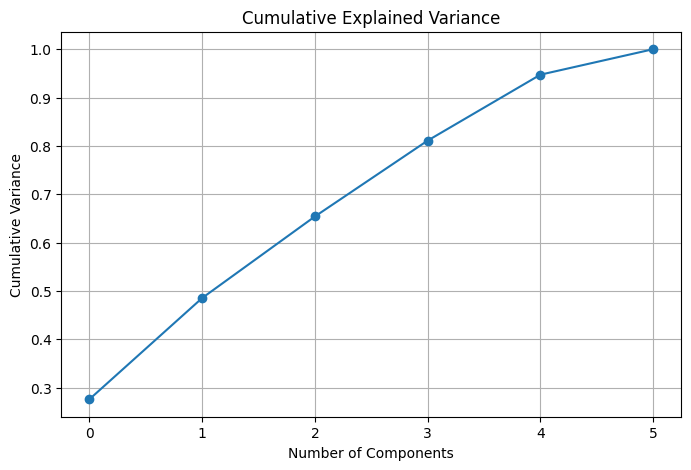

In [52]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

In [53]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components for 95% variance:", n_components_95)

Number of components for 95% variance: 6


In [54]:
pca_final = PCA(n_components=n_components_95)
reduced_data = pca_final.fit_transform(scaled_data)

print("Reduced data shape:", reduced_data.shape)

Reduced data shape: (1000, 6)


In [55]:
components = pd.DataFrame(
    pca_final.components_,
    columns=df_numeric.columns
)

print("PCA Loadings:")
display(components)

PCA Loadings:


,Unnamed: 0,heart_rate,sys_bp,dia_bp,ecg,event
0,-0.117731,0.008060,0.695715,0.699096,-0.100513,-0.056710
1,-0.488611,0.637868,0.064573,-0.118068,-0.075201,0.574994
2,-0.337163,0.166021,-0.064000,0.101455,0.857391,-0.330530
3,0.599596,-0.040936,0.195922,0.025367,0.487365,0.601876
4,0.522669,0.748612,-0.090495,0.125396,-0.101204,-0.363650
5,-0.031962,-0.058307,-0.679073,0.686049,-0.036834,0.249838


In [56]:
important_features = components.abs().idxmax(axis=1)

print("Most important feature in each PC:")
print(important_features)

Most important feature in each PC:
0        dia_bp
1    heart_rate
2           ecg
3         event
4    heart_rate
5        dia_bp
dtype: object


# **3. Conduct PCA on on financial transactions..dataset provided complex_fraud_dataset.csv**

In [57]:
from google.colab import files
uploaded = files.upload()

Saving complex_fraud_dataset.csv to complex_fraud_dataset.csv


In [58]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('complex_fraud_dataset.csv')

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

First 5 rows:


,amount,balance,hour,day,time_since_last,distance,speed,merchant_risk,cardholder_risk,device,ip_risk,z_score,is_fraud
0,70,4862,18,4,1200.44,11,29,0.07,0.03,1,0.07,-0.46,0
1,62,4840,13,1,1347.32,4,32,0.09,0.06,1,0.06,-0.96,0
2,51,4258,10,3,1951.90,6,31,0.03,0.01,1,0.09,-0.26,0
3,48,4708,11,3,1235.69,5,25,0.18,0.05,1,0.07,0.00,0
4,64,3040,17,3,1483.73,8,20,0.05,0.17,1,0.04,-0.79,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   amount           5000 non-null   int64  
 1   balance          5000 non-null   int64  
 2   hour             5000 non-null   int64  
 3   day              5000 non-null   int64  
 4   time_since_last  5000 non-null   float64
 5   distance         5000 non-null   int64  
 6   speed            5000 non-null   int64  
 7   merchant_risk    5000 non-null   float64
 8   cardholder_risk  5000 non-null   float64
 9   device           5000 non-null   int64  
 10  ip_risk          5000 non-null   float64
 11  z_score          5000 non-null   float64
 12  is_fraud         5000 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 507.9 KB


In [60]:
# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# OPTIONAL: Drop fraud label if present (important!)
df_numeric = df_numeric.drop(columns=['is_fraud', 'fraud_label'], errors='ignore')

# Handle missing values
df_numeric = df_numeric.fillna(df_numeric.mean())

print("Shape of numeric data:", df_numeric.shape)

Shape of numeric data: (5000, 12)


In [61]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

In [62]:
pca = PCA()
pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_

print("Explained Variance:\n", explained_variance)

Explained Variance:
 [6.81267541e-01 8.58923552e-02 8.24783916e-02 8.15877150e-02
 3.70990588e-02 1.24095486e-02 6.97703343e-03 5.02147216e-03
 3.33661093e-03 2.26029235e-03 1.34480987e-03 3.25170710e-04]


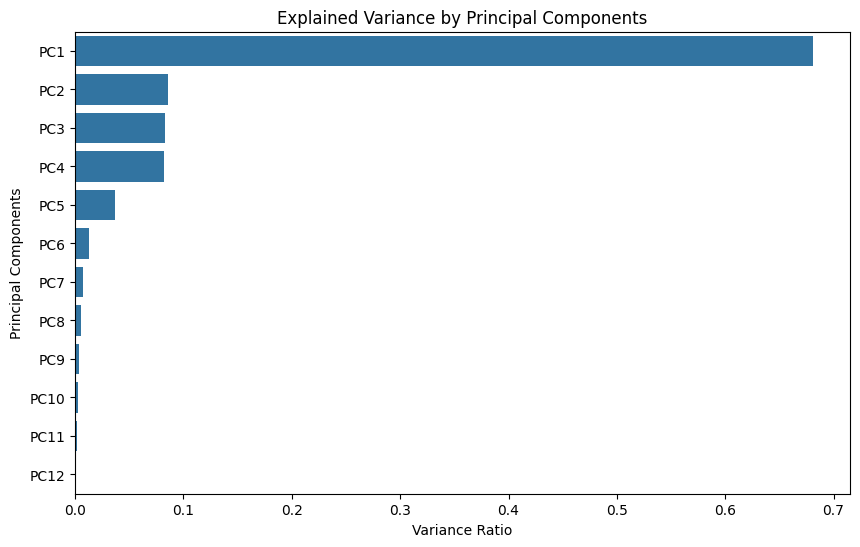

In [63]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=explained_variance,
    y=[f'PC{i+1}' for i in range(len(explained_variance))]
)
plt.title("Explained Variance by Principal Components")
plt.xlabel("Variance Ratio")
plt.ylabel("Principal Components")
plt.show()

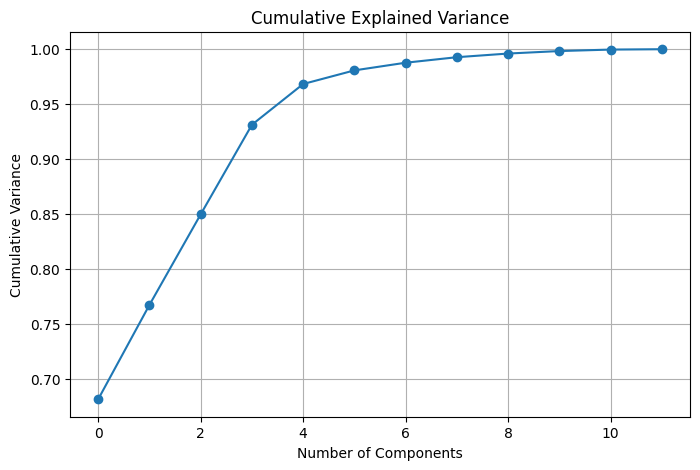

In [64]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

In [65]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Components needed for 95% variance:", n_components_95)

Components needed for 95% variance: 5


In [66]:
pca_final = PCA(n_components=n_components_95)
reduced_data = pca_final.fit_transform(scaled_data)

print("Reduced data shape:", reduced_data.shape)

Reduced data shape: (5000, 5)


In [67]:
components = pd.DataFrame(
    pca_final.components_,
    columns=df_numeric.columns
)

print("PCA Loadings:")
display(components)

PCA Loadings:


,amount,balance,hour,day,time_since_last,distance,speed,merchant_risk,cardholder_risk,device,ip_risk,z_score
0,-0.343164,-0.001600,0.267816,-0.002306,0.325178,-0.342264,-0.345728,-0.338666,-0.013321,0.347974,-0.345784,-0.335511
1,0.000865,0.552465,0.028279,0.637893,-0.002700,0.002756,0.005776,0.003348,-0.535594,-0.004563,0.007262,0.008957
2,-0.002275,0.706616,-0.005139,-0.017708,0.010544,-0.002172,-0.005136,-0.002328,0.707194,0.003664,-0.001289,-0.007896
3,-0.004903,-0.441776,-0.010228,0.769812,0.005938,-0.003046,-0.001015,-0.006698,0.460397,0.002713,0.000516,-0.005661
4,0.091476,-0.016632,0.962730,-0.009936,-0.108208,0.093401,0.088041,0.096293,0.028233,-0.086696,0.095047,0.098000


In [68]:
important_features = components.abs().idxmax(axis=1)

print("Most important feature in each principal component:")
print(important_features)

Most important feature in each principal component:
0             device
1                day
2    cardholder_risk
3                day
4               hour
dtype: object


# **4. Conduct PCA on on load_breast_cancer**

In [69]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
data = load_breast_cancer()

X = data.data
y = data.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)

print("First 5 rows:")
display(df.head())

print("\nTarget values (0 = malignant, 1 = benign):")
print(y[:10])

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target values (0 = malignant, 1 = benign):
[0 0 0 0 0 0 0 0 0 0]


In [71]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [72]:
pca = PCA()
pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_

print("Explained Variance:\n", explained_variance)

Explained Variance:
 [4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


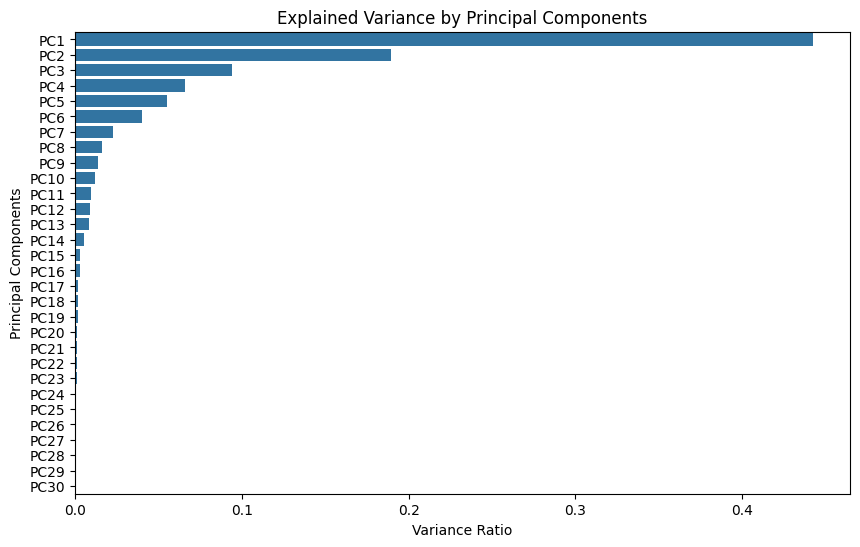

In [73]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=explained_variance,
    y=[f'PC{i+1}' for i in range(len(explained_variance))]
)
plt.title("Explained Variance by Principal Components")
plt.xlabel("Variance Ratio")
plt.ylabel("Principal Components")
plt.show()

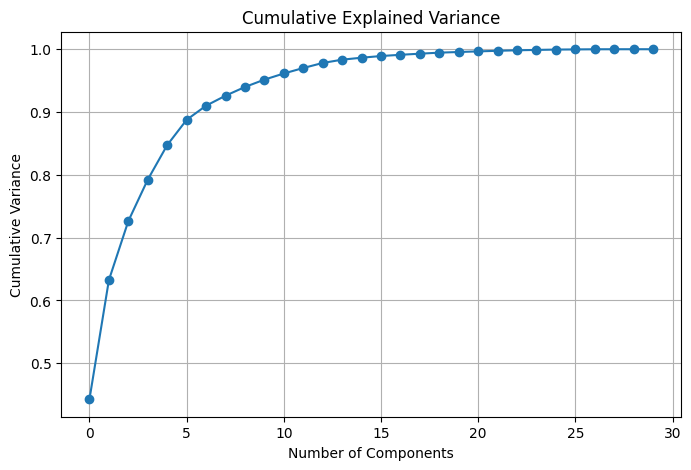

In [74]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

In [75]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components for 95% variance:", n_components_95)

Number of components for 95% variance: 10


In [76]:
pca_final = PCA(n_components=n_components_95)
reduced_data = pca_final.fit_transform(scaled_data)

print("Reduced data shape:", reduced_data.shape)

Reduced data shape: (569, 10)


In [77]:
components = pd.DataFrame(
    pca_final.components_,
    columns=data.feature_names
)

print("PCA Loadings:")
display(components)

PCA Loadings:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
1,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339
2,-0.008531,0.064550,-0.009314,0.028700,-0.104292,-0.074092,0.002734,-0.025564,-0.040240,-0.022574,...,-0.047507,-0.042298,-0.048547,-0.011902,-0.259798,-0.236076,-0.173057,-0.170344,-0.271313,-0.232791
3,-0.041409,0.603050,-0.041983,-0.053434,-0.159383,-0.031795,-0.019123,-0.065336,-0.067125,-0.048587,...,-0.015417,0.632808,-0.013803,-0.025895,-0.017652,0.091328,0.073951,-0.006007,0.036251,0.077053
4,-0.037786,0.049469,-0.037375,-0.010331,0.365089,-0.011704,-0.086375,0.043861,0.305941,0.044424,...,0.004407,0.092883,-0.007454,0.027391,0.324435,-0.121804,-0.188519,-0.043332,0.244559,-0.094423
5,0.018741,-0.032179,0.017308,-0.001888,-0.286374,-0.014131,-0.009344,-0.052050,0.356458,-0.119431,...,-0.000291,-0.050008,0.008501,-0.025164,-0.369255,0.047706,0.028379,-0.030873,0.498927,-0.080224
6,-0.124088,0.011400,-0.114477,-0.051653,-0.140669,0.030918,-0.107520,-0.150482,-0.093891,0.295760,...,-0.009710,0.009871,-0.000446,0.067832,-0.108831,0.140473,-0.060488,-0.167967,-0.018491,0.374658
7,-0.007452,0.130675,-0.018687,0.034674,-0.288975,-0.151396,-0.072827,-0.152322,-0.231531,-0.177121,...,0.042619,0.036252,0.030559,0.079394,0.205852,0.084020,0.072468,-0.036171,0.228225,0.048361
8,-0.223110,0.112699,-0.223739,-0.195586,0.006425,-0.167841,0.040591,-0.111971,0.256040,-0.123741,...,-0.112141,0.103341,-0.109614,-0.080732,0.112316,-0.100678,0.161909,0.060488,0.064638,-0.134174
9,0.095486,0.240934,0.086386,0.074956,-0.069293,0.012936,-0.135602,0.008055,0.572069,0.081103,...,0.077362,0.029551,0.050508,0.069921,-0.128305,-0.172134,-0.311639,-0.076648,-0.029563,0.012610


In [78]:
important_features = components.abs().idxmax(axis=1)

print("Most important feature in each principal component:")
print(important_features)

Most important feature in each principal component:
0        mean concave points
1     mean fractal dimension
2              texture error
3              worst texture
4            mean smoothness
5             worst symmetry
6    worst fractal dimension
7           smoothness error
8            concavity error
9              mean symmetry
dtype: object
